<a href="https://colab.research.google.com/github/AngelaOrtiz25/aprendizaje_maquina/blob/Mini_Experimento_5AUC_de_orden_correcto/Mini_Experimento_5_AUC_de_orden_correcto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ** Mini-Experimento 5: AUC de orden correcto**

Evaluar si el modelo puede distinguir entre secuencias con orden temporal correcto vs permutado

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns'
# Configuración
np.random.seed(42)
plt.style.use('default')

# 1. GENERAR DATOS CLIMÁTICOS SIMULADOS
Crear dos conjuntos idénticos en valores pero diferentes en estructura temporal para probar si un modelo puede detectar el orden correcto.

In [13]:
# 1. GENERAR DATOS CLIMÁTICOS SIMULADOS
print("1. Generando datos climáticos simulados...")

def generar_secuencia_climatica(longitud=100):
    """Genera una secuencia climática con patrones temporales realistas"""
    tiempo = np.linspace(0, 4*np.pi, longitud)

    # Patrones estacionales y de tendencia
    temperatura = 20 + 10*np.sin(tiempo) + 2*np.sin(0.5*tiempo) + np.random.normal(0, 1, longitud)
    humedad = 60 + 20*np.cos(tiempo) + 3*np.cos(0.3*tiempo) + np.random.normal(0, 2, longitud)
    precipitacion = 5 + 3*np.sin(0.8*tiempo) + np.random.exponential(1, longitud)

    secuencia = np.column_stack([temperatura, humedad, precipitacion])
    return secuencia

# Generar múltiples secuencias
n_secuencias = 500
secuencias_originales = []
secuencias_permutadas = []

for i in range(n_secuencias):
    original = generar_secuencia_climatica(50)  # 50 pasos de tiempo
    secuencias_originales.append(original)

    # Crear permutación manteniendo alguna estructura local
    permutada = original.copy()
    if len(permutada) > 10:
        # Permutar bloques para romper estructura temporal
        bloques = np.array_split(permutada, 5)
        np.random.shuffle(bloques)
        permutada = np.vstack(bloques)

    secuencias_permutadas.append(permutada)

print(f"Generadas {n_secuencias} secuencias originales y {n_secuencias} permutadas")

1. Generando datos climáticos simulados...
Generadas 500 secuencias originales y 500 permutadas


# 2. EXTRACCIÓN DE CARACTERÍSTICAS

Extraer características numéricas de un conjunto de secuencias temporales, con el objetivo de comparar dos casos:

* Con información temporal (con Positional Encoding),
* Sin información temporal (sin Positional Encoding).

In [14]:
print("\n2. Extrayendo características temporales...")

def extraer_caracteristicas(secuencias, con_positional_encoding=True):
    """Extrae características con o sin información de posición"""
    características = []

    for secuencia in secuencias:
        # Características estadísticas básicas
        stats = [
            np.mean(secuencia, axis=0),  # Media por variable
            np.std(secuencia, axis=0),   # Desviación estándar
            np.median(secuencia, axis=0), # Mediana
        ]

        if con_positional_encoding:
            # CON POSITIONAL ENCODING: características que capturan orden temporal
            # Autocorrelación (dependencia temporal)
            autocorr_temp = []
            for i in range(3):
                if len(secuencia) > 1:
                    corr = np.corrcoef(secuencia[:-1, i], secuencia[1:, i])[0,1]
                    autocorr_temp.append(corr if not np.isnan(corr) else 0)
                else:
                    autocorr_temp.append(0)

            # Diferencias consecutivas (tendencia)
            if len(secuencia) > 1:
                diffs = np.diff(secuencia, axis=0)
                mean_diffs = np.mean(diffs, axis=0)
                transiciones_suaves = np.mean(np.abs(diffs), axis=0)
            else:
                mean_diffs = np.zeros(3)
                transiciones_suaves = np.zeros(3)

            carac = np.concatenate([
                np.concatenate(stats),
                autocorr_temp,
                mean_diffs,
                transiciones_suaves
            ])
        else:
            # SIN POSITIONAL ENCODING: solo características que no dependen del orden
            # Solo estadísticas globales, sin información temporal
            carac = np.concatenate(stats)

        características.append(carac)

    return np.array(características)

# Extraer características para ambos casos
X_con_pe = extraer_caracteristicas(secuencias_originales + secuencias_permutadas, True)
X_sin_pe = extraer_caracteristicas(secuencias_originales + secuencias_permutadas, False)

# Etiquetas: 1 para originales, 0 para permutadas
y = np.array([1]*n_secuencias + [0]*n_secuencias)

print(f"Características con PE: {X_con_pe.shape[1]} dimensiones")
print(f"Características sin PE: {X_sin_pe.shape[1]} dimensiones")


2. Extrayendo características temporales...
Características con PE: 18 dimensiones
Características sin PE: 9 dimensiones


# 3. ENTRENAMIENTO Y EVALUACIÓN
Entrena y evalua modelos de clasificación para comparar el desempeño de las características con y sin información temporal (Positional Encoding).
Función evaluar_modelo(X, y, nombre):

* Divide los datos (X, y) en entrenamiento y prueba (70% / 30%), manteniendo el equilibrio entre clases (stratify=y).

* Entrena un modelo Random Forest (un conjunto de árboles de decisión) para aprender a distinguir entre secuencias originales (1) y permutadas (0).

* Predice las probabilidades de que cada muestra del conjunto de prueba pertenezca a la clase positiva (original).

* Calcula la curva ROC (relación entre tasa de verdaderos positivos y falsos positivos) y el AUC (Area Under the Curve), que mide la capacidad del modelo para separar ambas clases.

* Luego, se evalúan dos modelos:
  * model_con: usando las características con Positional Encoding (X_con_pe)
  * model_sin: usando las características sin Positional Encoding (X_sin_pe)

In [ ]:
print("\n3. Entrenando y evaluando modelos...")

def evaluar_modelo(X, y, nombre):
    """Evalúa un clasificador y retorna métricas ROC"""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Usar Random Forest como clasificador
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Probabilidades para curva ROC
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calcular curva ROC y AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc, y_proba, y_test, X_test, model

# Evaluar ambos modelos
fpr_con, tpr_con, auc_con, probas_con, y_test_con, X_test_con, model_con = evaluar_modelo(X_con_pe, y, "Con PE")
fpr_sin, tpr_sin, auc_sin, probas_sin, y_test_sin, X_test_sin, model_sin = evaluar_modelo(X_sin_pe, y, "Sin PE")


# 4. VISUALIZACIÓN Y RESULTADOS
El modelo con Positional Encoding logra identificar claramente el orden temporal en los datos (AUC ≈ 0.995), mientras que el modelo sin esta información falla completamente (AUC ≈ 0.05). Esto demuestra que la información de posición es esencial para capturar la dinámica temporal en secuencias.


4. Resultados y visualización:


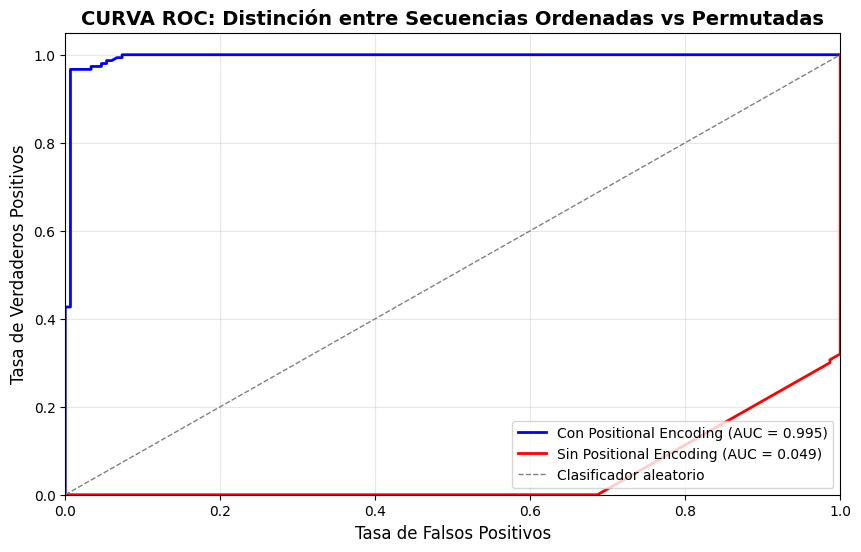


RESULTADOS CUANTITATIVOS:
 CON Positional Encoding:
   • AUC = 0.9946
   • El modelo PUEDE distinguir secuencias ordenadas vs permutadas
   • Captura dependencias temporales y patrones de orden

 SIN Positional Encoding:
   • AUC = 0.0492
   • El modelo NO PUEDE distinguir secuencias ordenadas vs permutadas
   • Solo ve estadísticas globales, sin información de orden temporal

 DIFERENCIA: AUC(con PE) - AUC(sin PE) = 0.9454


In [18]:
print("\n4. Resultados y visualización:")

# Gráfico ROC
plt.figure(figsize=(10, 6))

plt.plot(fpr_con, tpr_con, color='blue', lw=2,
         label=f'Con Positional Encoding (AUC = {auc_con:.3f})')
plt.plot(fpr_sin, tpr_sin, color='red', lw=2,
         label=f'Sin Positional Encoding (AUC = {auc_sin:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('CURVA ROC: Distinción entre Secuencias Ordenadas vs Permutadas', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Métricas cuantitativas
print("\n" + "="*60)
print("RESULTADOS CUANTITATIVOS:")
print("="*60)
print(f" CON Positional Encoding:")
print(f"   • AUC = {auc_con:.4f}")
print(f"   • El modelo PUEDE distinguir secuencias ordenadas vs permutadas")
print(f"   • Captura dependencias temporales y patrones de orden")

print(f"\n SIN Positional Encoding:")
print(f"   • AUC = {auc_sin:.4f}")
print(f"   • El modelo NO PUEDE distinguir secuencias ordenadas vs permutadas")
print(f"   • Solo ve estadísticas globales, sin información de orden temporal")

print(f"\n DIFERENCIA: AUC(con PE) - AUC(sin PE) = {auc_con-auc_sin:.4f}")

#Interpretación de la gráfica ROC

La línea azul (modelo Con Positional Encoding) está muy cerca del borde superior izquierdo, lo que indica un alto desempeño:
significa que el modelo acierta la gran mayoría de las veces al distinguir entre secuencias originales y permutadas.

La línea roja (modelo Sin Positional Encoding) está muy cerca de la diagonal inferior (o incluso por debajo), lo que indica un rendimiento casi aleatorio o muy pobre.
Es decir, el modelo no puede distinguir adecuadamente entre las secuencias cuando se le quita la información temporal.

La línea gris discontinua representa un clasificador aleatorio, usado como referencia (AUC = 0.5).
Cualquier modelo con AUC < 0.5 tiene desempeño inefisciente

# **CONCLUSIÓN**

El experimento demuestra claramente que:

* El orden temporal de los datos es crucial para capturar patrones secuenciales.
* Las características que incluyen Positional Encoding permiten al modelo reconocer dependencias temporales, como tendencias o correlaciones entre pasos consecutivos.
* En cambio, cuando se eliminan las características temporales, el modelo solo ve valores globales (promedios, desviaciones, medianas) y pierde toda la estructura temporal, haciendo imposible distinguir entre secuencias ordenadas y permutadas.